# Bayesian k-NN probability heat map

Set `DATASET` to `moon`, `iris`, or `gaussian`, then run the cells.

In [19]:
import sys
from pathlib import Path
import warnings

warnings.filterwarnings(
    "ignore",
    message="A worker stopped while some jobs were given to the executor.*",
    category=UserWarning,
)

project_root = Path.cwd()
if not (project_root / "bayesian_knn").is_dir() and (project_root.parent / "bayesian_knn").is_dir():
    project_root = project_root.parent
if (project_root / "bayesian_knn").is_dir():
    sys.path.insert(0, str(project_root))

from bayesian_knn.experiments.classification_2d import (
    format_convergence_history,
    plot_probability_heatmap,
    run_2d_classification_experiment,
)

In [20]:
DATASET = "moon"  # Other options: "moon", "iris", "gaussian"

DATA_PARAMETERS = {
    "n_samples": 1200,
    "noise": 0.24,
    "random_state": 7,
    "feature_indices": (0, 1),
    "mean_distance": 3.0,
    "standard_deviation": 1.0,
}

SPLIT_PARAMETERS = {
    "test_size": 0.30,
    "split_random_state": 7,
}

MODEL_PARAMETERS = {
    "representation": "identity",
    "n_estimators": "auto",
    "max_estimators": 1500,
    "tolerance": 0.001,
    "convergence_metric": "median",
    "convergence_size": 256,
    "cv": 5,
    "max_neighbors": None,
    "weights": "distance",
    "n_jobs": -1,
    "random_state": 12,
}

PLOT_PARAMETERS = {
    "padding": 0.55,
    "grid_size": 150,
    "class_label": None,
    "output_path": None,
}

In [21]:
result = run_2d_classification_experiment(
    DATASET,
    dataset_parameters=DATA_PARAMETERS,
    **SPLIT_PARAMETERS,
    model_parameters=MODEL_PARAMETERS,
)
print(f"dataset: {result.dataset}")
print(f"test accuracy: {result.test_accuracy:.3f}")
print(f"estimators used: {result.model.n_estimators_}")
print(f"converged: {result.model.converged_}")
print(format_convergence_history(result))

dataset: moon
test accuracy: 0.933
estimators used: 1500
converged: True
20 estimators: initial ensemble
40 estimators: median probability change = 0.011755
80 estimators: median probability change = 0.007517
160 estimators: median probability change = 0.004755
320 estimators: median probability change = 0.003361
640 estimators: median probability change = 0.003596
1280 estimators: median probability change = 0.001082
1500 estimators: median probability change = 0.000803


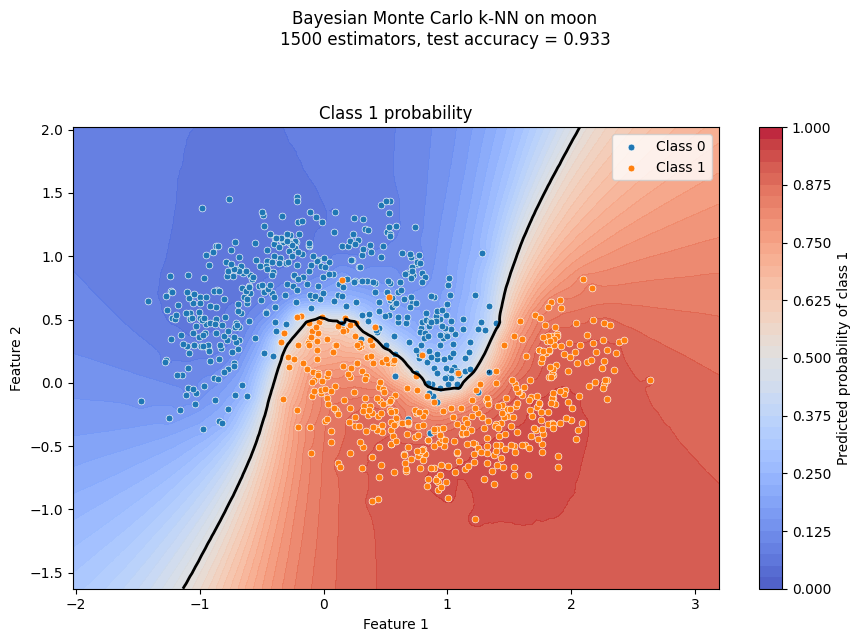

In [22]:
_ = plot_probability_heatmap(result, **PLOT_PARAMETERS)